## Load the Feature Dataset

In [3]:
import numpy as np
import json

data = np.load("FeatureModels/Features.npz", allow_pickle=True)

metadata = json.loads(data["metadata_json"].item())
feature_names = data["feature_names"].tolist()

X0 = data["X_train_scaled_class_0"]
X1 = data["X_train_scaled_class_1"]

print(metadata)
print("Class 0:", X0.shape)
print("Class 1:", X1.shape)
print("First 10 features:", feature_names[:10])

{'description': 'Lean curated handcrafted + CSP EEG features for MI class separability analysis.', 'sampling_rate': 250, 'random_state': 42, 'n_csp_components': 6, 'csp_reg': 1e-06, 'bands': {'mu': [8, 12], 'alpha': [8, 13], 'low_alpha': [8, 10], 'high_alpha': [10, 13], 'beta': [13, 30]}, 'feature_count': 424, 'channel_names': ['C3', 'Cz', 'C4', 'ch3', 'ch4', 'ch5', 'ch6', 'C3_clean_025Cz', 'C3_clean_050Cz', 'C3_clean_075Cz', 'C3_clean_100Cz', 'C4_clean_025Cz', 'C4_clean_050Cz', 'C4_clean_075Cz', 'C4_clean_100Cz', 'C3_clean', 'C4_clean', 'C3_minus_C4', 'C4_minus_C3', 'C3clean025_minus_C4clean025', 'C3clean050_minus_C4clean050', 'C3clean075_minus_C4clean075', 'C3clean100_minus_C4clean100', 'C3clean_minus_C4clean', 'C3_C4_mean', 'C3_Cz_mean', 'C4_Cz_mean', 'C3_Cz_C4_mean', 'C3_smooth_421', 'Cz_smooth_211', 'C4_smooth_421', 'C3_smooth_611', 'C4_smooth_611', 'C3_smooth_532', 'C4_smooth_532', 'C3_laplacian_simple', 'C4_laplacian_simple', 'Cz_laplacian_simple', 'C3_laplacian_strong', 'C4_lap

## Feature Set Score

Loaded: FeatureModels/Features.npz
Feature count: 424
Metadata:
{'description': 'Lean curated handcrafted + CSP EEG features for MI class separability analysis.', 'sampling_rate': 250, 'random_state': 42, 'n_csp_components': 6, 'csp_reg': 1e-06, 'bands': {'mu': [8, 12], 'alpha': [8, 13], 'low_alpha': [8, 10], 'high_alpha': [10, 13], 'beta': [13, 30]}, 'feature_count': 424, 'channel_names': ['C3', 'Cz', 'C4', 'ch3', 'ch4', 'ch5', 'ch6', 'C3_clean_025Cz', 'C3_clean_050Cz', 'C3_clean_075Cz', 'C3_clean_100Cz', 'C4_clean_025Cz', 'C4_clean_050Cz', 'C4_clean_075Cz', 'C4_clean_100Cz', 'C3_clean', 'C4_clean', 'C3_minus_C4', 'C4_minus_C3', 'C3clean025_minus_C4clean025', 'C3clean050_minus_C4clean050', 'C3clean075_minus_C4clean075', 'C3clean100_minus_C4clean100', 'C3clean_minus_C4clean', 'C3_C4_mean', 'C3_Cz_mean', 'C4_Cz_mean', 'C3_Cz_C4_mean', 'C3_smooth_421', 'Cz_smooth_211', 'C4_smooth_421', 'C3_smooth_611', 'C4_smooth_611', 'C3_smooth_532', 'C4_smooth_532', 'C3_laplacian_simple', 'C4_laplacia

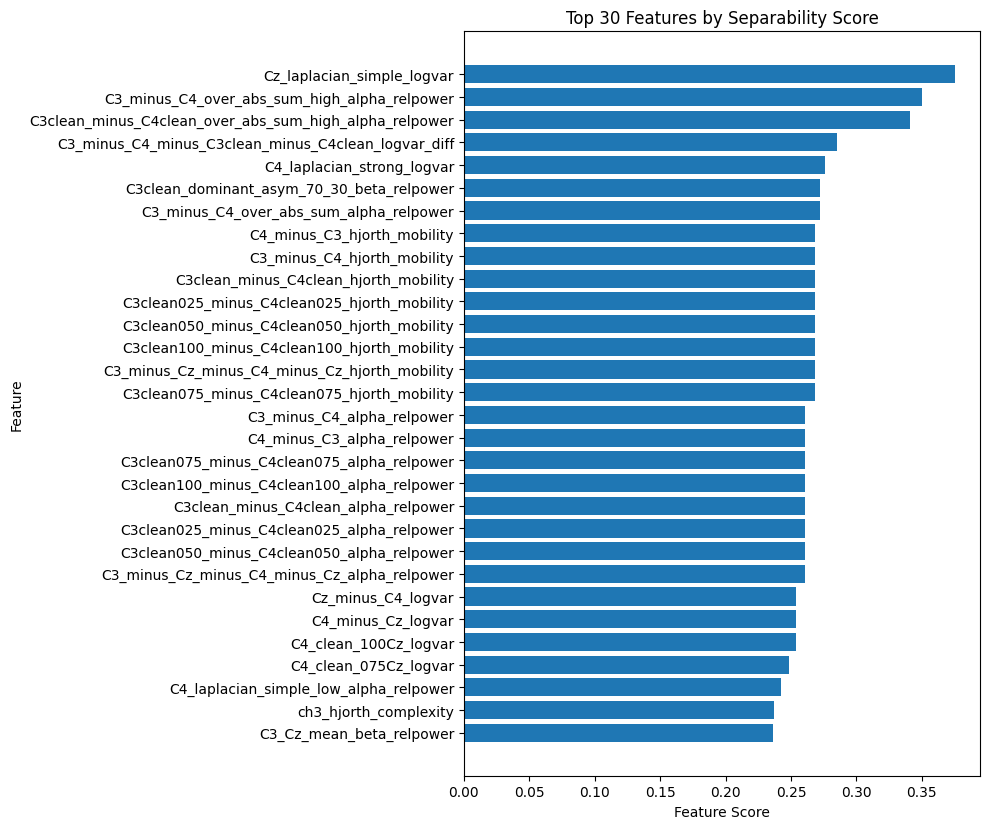

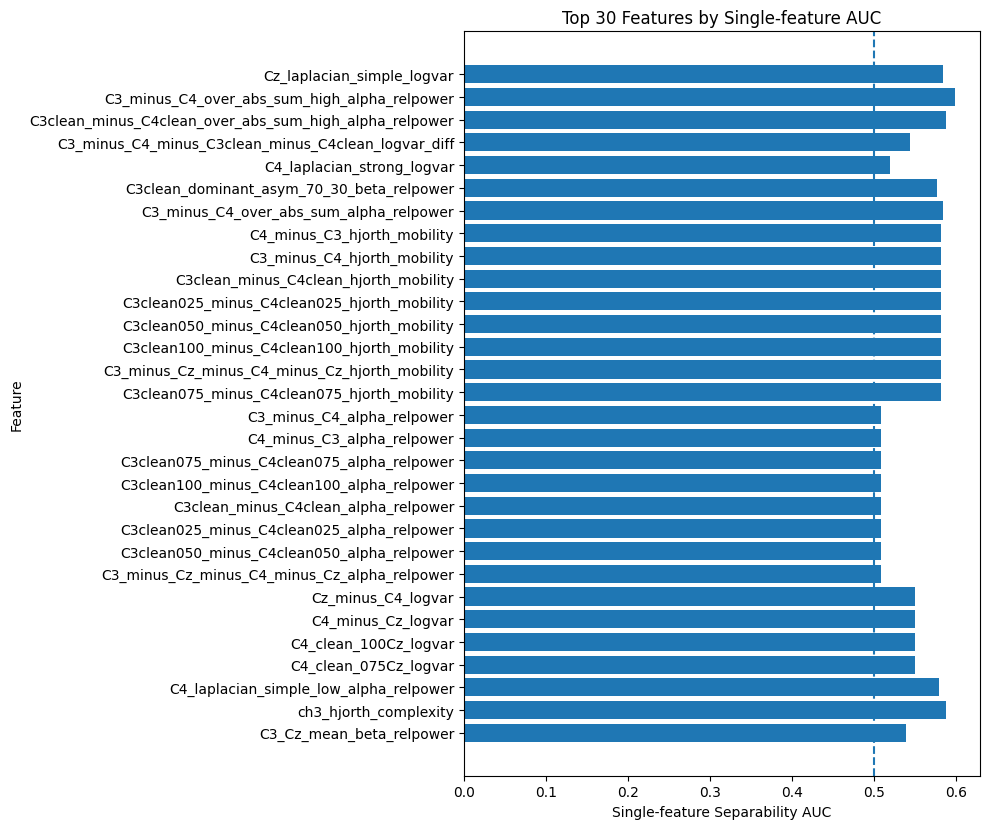

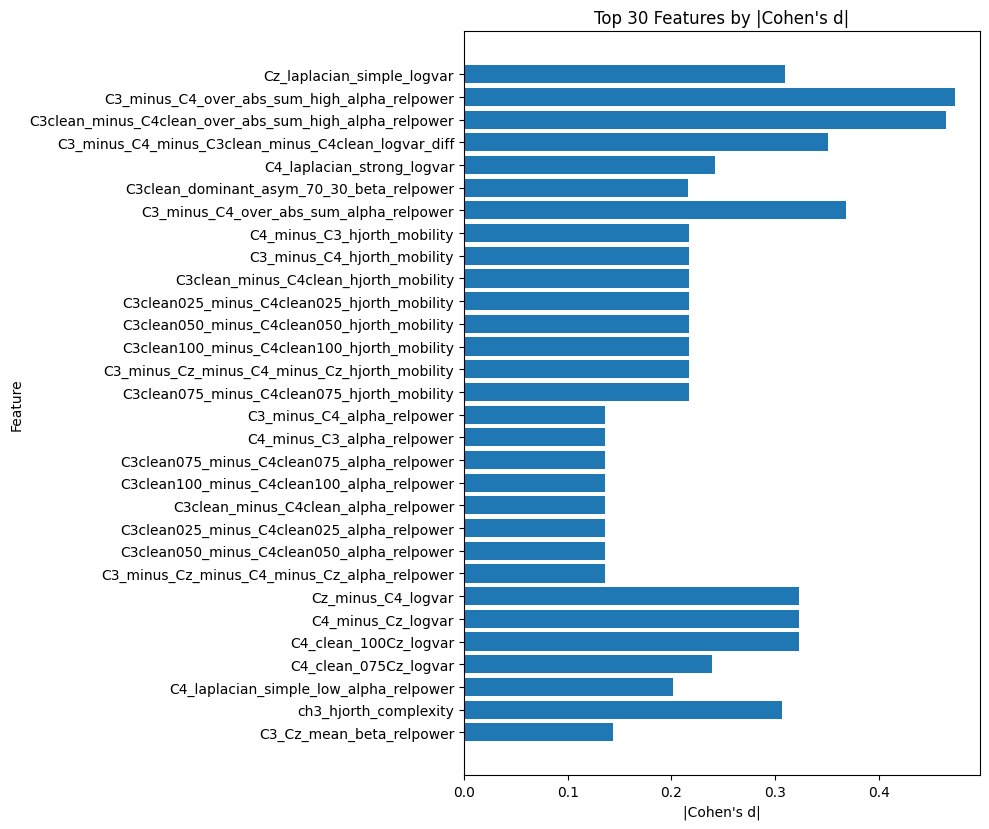

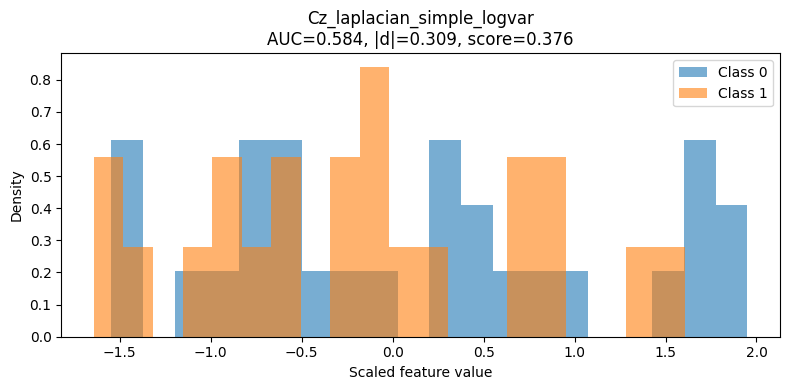

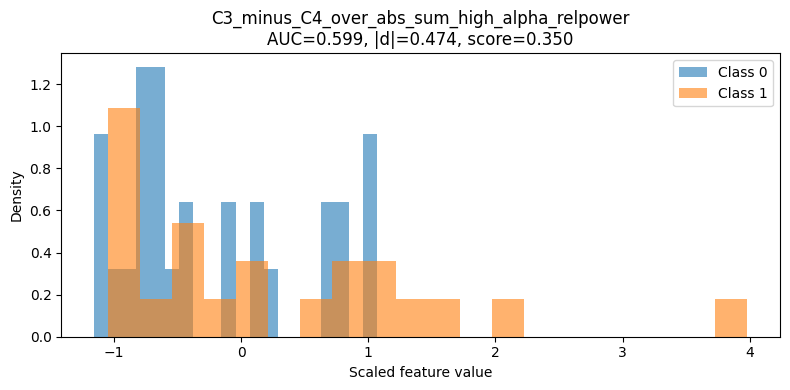

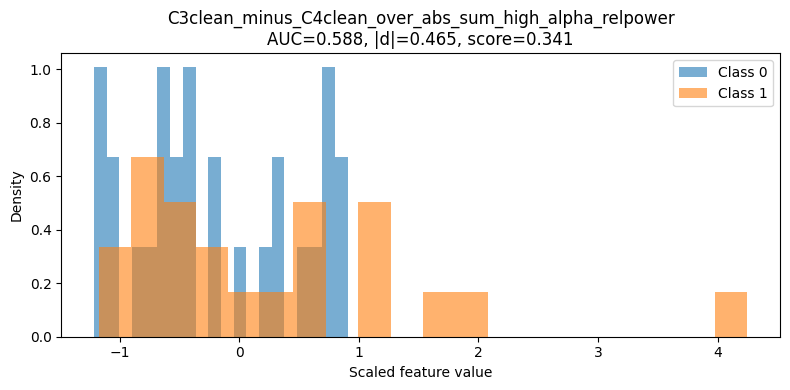

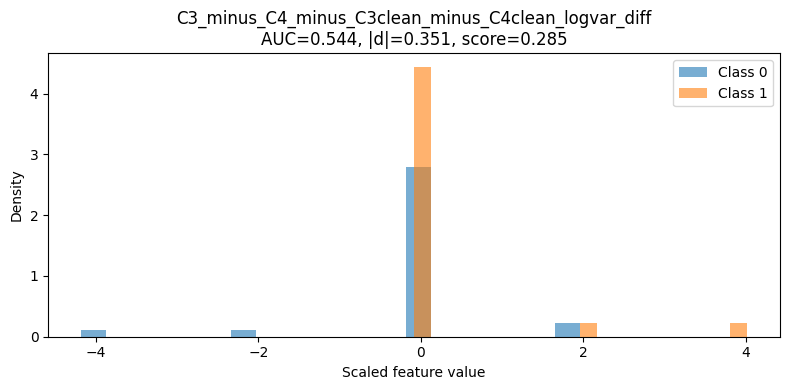

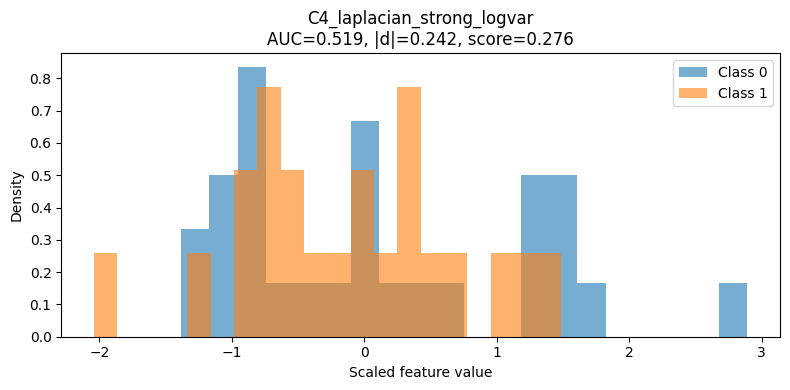

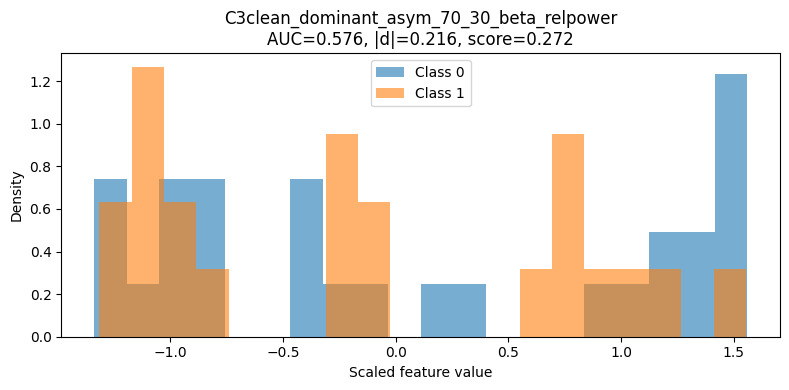

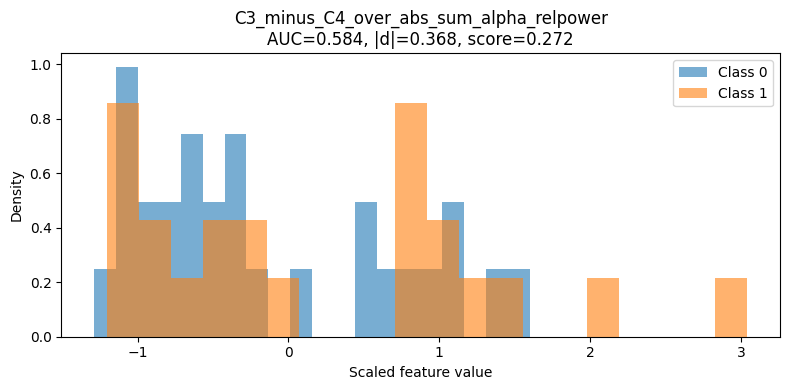

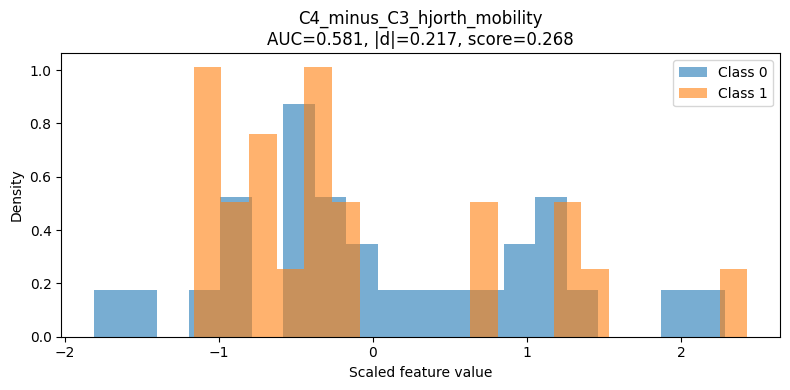

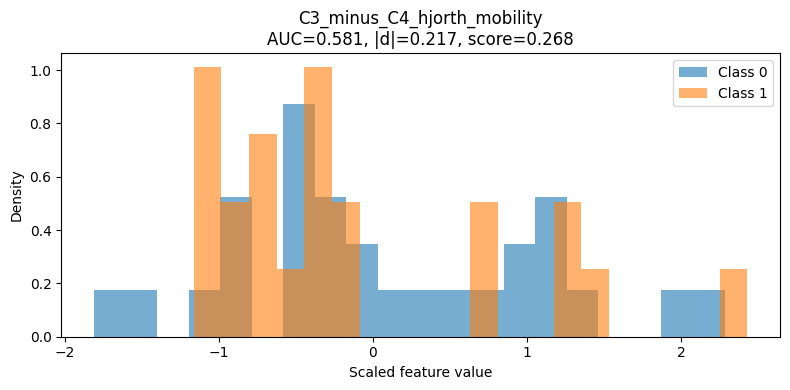

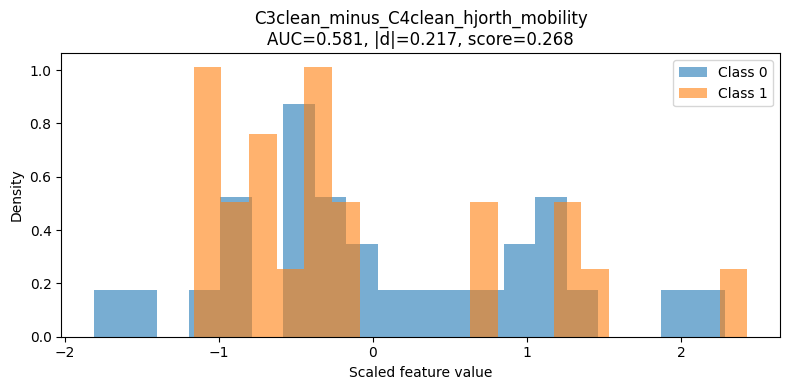

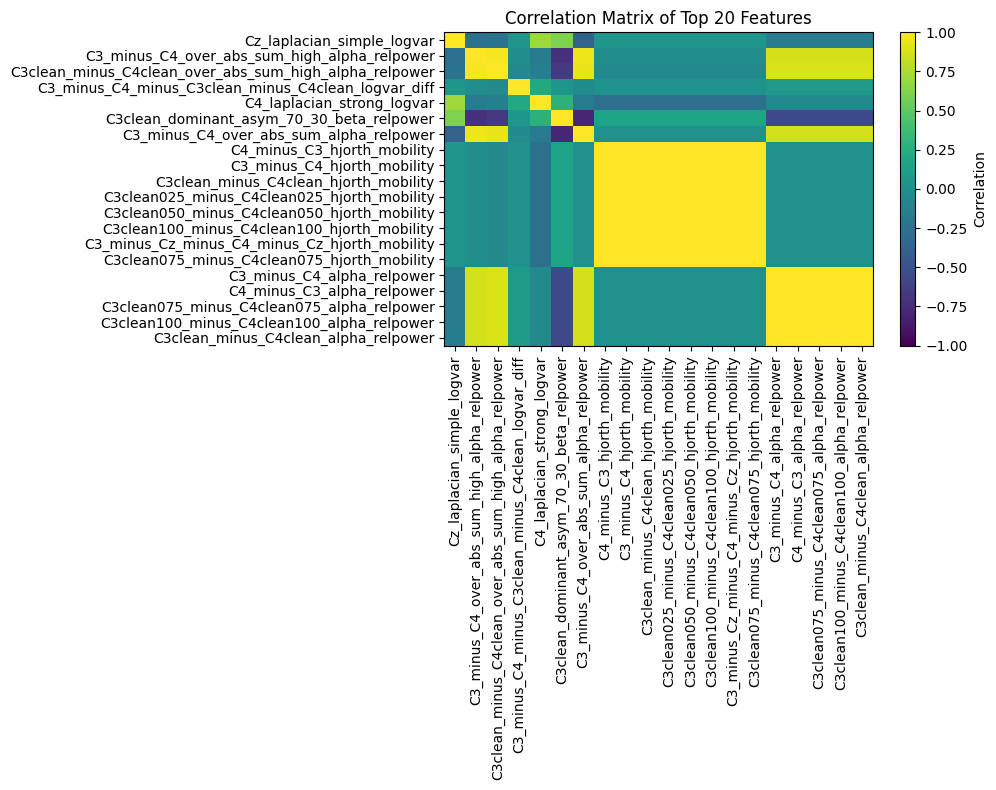

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler

FEATURE_PATH = "FeatureModels/Features.npz"
OUTPUT_DIR = "FeatureModels"

TOP_N = 30
TOP_N_FOR_SET_SCORE = 20
RANDOM_STATE = 42

USE_SPLIT = "train"  # "train", "val", "test", or "all"

os.makedirs(OUTPUT_DIR, exist_ok=True)

data = np.load(FEATURE_PATH, allow_pickle=True)

metadata = json.loads(data["metadata_json"].item())
feature_names = data["feature_names"].tolist()

print("Loaded:", FEATURE_PATH)
print("Feature count:", len(feature_names))
print("Metadata:")
print(metadata)

if USE_SPLIT == "train":
    X = data["X_train_scaled"]
    y = data["y_train"]

elif USE_SPLIT == "val":
    X = data["X_val_scaled"]
    y = data["y_val"]

elif USE_SPLIT == "test":
    X = data["X_test_scaled"]
    y = data["y_test"]

elif USE_SPLIT == "all":
    X = np.concatenate(
        [
            data["X_train_scaled"],
            data["X_val_scaled"],
            data["X_test_scaled"]
        ],
        axis=0
    )

    y = np.concatenate(
        [
            data["y_train"],
            data["y_val"],
            data["y_test"]
        ],
        axis=0
    )

else:
    raise ValueError("USE_SPLIT must be 'train', 'val', 'test', or 'all'.")

X = np.asarray(X, dtype=np.float64)
y = np.asarray(y)

print("\nUsing split:", USE_SPLIT)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance:", np.unique(y, return_counts=True))

classes = np.unique(y)

if len(classes) != 2:
    raise ValueError(f"This analysis expects binary classes, got {classes}")

class_0 = classes[0]
class_1 = classes[1]

X0 = X[y == class_0]
X1 = X[y == class_1]

n_features = X.shape[1]

if n_features != len(feature_names):
    raise ValueError(
        f"Feature name mismatch: X has {n_features} columns, "
        f"but feature_names has {len(feature_names)} names."
    )


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def cohens_d(x0, x1, eps=1e-12):
    """
    Cohen's d:
        positive means class 1 has higher mean than class 0.
    """

    x0 = np.asarray(x0, dtype=np.float64)
    x1 = np.asarray(x1, dtype=np.float64)

    n0 = len(x0)
    n1 = len(x1)

    mean0 = np.mean(x0)
    mean1 = np.mean(x1)

    var0 = np.var(x0, ddof=1)
    var1 = np.var(x1, ddof=1)

    pooled_std = np.sqrt(
        ((n0 - 1) * var0 + (n1 - 1) * var1) / max(n0 + n1 - 2, 1)
    )

    return (mean1 - mean0) / (pooled_std + eps)


def safe_auc(y_true, values):
    """
    Returns:
        raw_auc: normal ROC AUC
        sep_auc: direction-independent AUC, always >= 0.5
    """

    try:
        raw_auc = roc_auc_score(y_true, values)
    except ValueError:
        raw_auc = np.nan

    if np.isnan(raw_auc):
        sep_auc = np.nan
    else:
        sep_auc = max(raw_auc, 1.0 - raw_auc)

    return raw_auc, sep_auc


def safe_mannwhitney(x0, x1):
    try:
        stat, p = mannwhitneyu(
            x0,
            x1,
            alternative="two-sided"
        )
    except Exception:
        stat, p = np.nan, np.nan

    return stat, p


def benjamini_hochberg_fdr(p_values):
    """
    Benjamini-Hochberg FDR correction.
    Returns corrected q-values.
    """

    p_values = np.asarray(p_values, dtype=np.float64)

    n = len(p_values)
    q_values = np.full(n, np.nan)

    valid = ~np.isnan(p_values)

    if np.sum(valid) == 0:
        return q_values

    p_valid = p_values[valid]
    valid_indices = np.where(valid)[0]

    order = np.argsort(p_valid)
    ranked_p = p_valid[order]

    q = ranked_p * n / (np.arange(1, len(ranked_p) + 1))

    # Make monotonic from right to left
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)

    corrected = np.empty_like(p_valid)
    corrected[order] = q

    q_values[valid_indices] = corrected

    return q_values


def minmax_01(values):
    values = np.asarray(values, dtype=np.float64)

    out = np.zeros_like(values, dtype=np.float64)
    valid = ~np.isnan(values)

    if np.sum(valid) == 0:
        return out

    v = values[valid]
    v_min = np.min(v)
    v_max = np.max(v)

    if abs(v_max - v_min) < 1e-12:
        out[valid] = 0.0
    else:
        out[valid] = (v - v_min) / (v_max - v_min)

    return out


# ============================================================
# BASIC FEATURE SEPARABILITY METRICS
# ============================================================

rows = []

for i, feature_name in enumerate(feature_names):
    values = X[:, i]

    values0 = X0[:, i]
    values1 = X1[:, i]

    mean0 = np.mean(values0)
    mean1 = np.mean(values1)

    std0 = np.std(values0, ddof=1)
    std1 = np.std(values1, ddof=1)

    d = cohens_d(values0, values1)

    raw_auc, sep_auc = safe_auc(y, values)

    mw_stat, mw_p = safe_mannwhitney(values0, values1)

    rows.append({
        "feature_index": i,
        "feature_name": feature_name,

        "class_0_mean": mean0,
        "class_1_mean": mean1,
        "class_0_std": std0,
        "class_1_std": std1,

        "mean_diff_class1_minus_class0": mean1 - mean0,

        "cohens_d": d,
        "abs_cohens_d": abs(d),

        "raw_auc": raw_auc,
        "separability_auc": sep_auc,
        "auc_distance_from_random": abs(sep_auc - 0.5) * 2.0 if not np.isnan(sep_auc) else np.nan,

        "mannwhitney_stat": mw_stat,
        "mannwhitney_p": mw_p,
    })

results_df = pd.DataFrame(rows)

# FDR correction
results_df["mannwhitney_q_fdr"] = benjamini_hochberg_fdr(
    results_df["mannwhitney_p"].values
)


# ============================================================
# MUTUAL INFORMATION
# ============================================================

print("\nComputing mutual information...")

try:
    mi = mutual_info_classif(
        X,
        y,
        discrete_features=False,
        random_state=RANDOM_STATE
    )
except Exception as e:
    print("Mutual information failed:", e)
    mi = np.zeros(n_features)

results_df["mutual_information"] = mi


# ============================================================
# REDUNDANCY / CORRELATION PENALTY
# ============================================================
# A feature gets penalized if it is highly correlated with many others.
# This does not mean the feature is bad, only that it may be redundant.

print("Computing redundancy penalties...")

corr = np.corrcoef(X, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

abs_corr = np.abs(corr)

# Ignore self-correlation
np.fill_diagonal(abs_corr, 0.0)

mean_abs_corr = np.mean(abs_corr, axis=1)
max_abs_corr = np.max(abs_corr, axis=1)

results_df["mean_abs_corr_to_other_features"] = mean_abs_corr
results_df["max_abs_corr_to_other_features"] = max_abs_corr

# Penalty: high mean correlation means less unique information.
# 1.0 = no penalty, 0.0 = very redundant
redundancy_penalty = 1.0 - np.clip(mean_abs_corr, 0.0, 1.0)
results_df["redundancy_penalty"] = redundancy_penalty


# ============================================================
# FINAL FEATURE SCORE
# ============================================================
# Components:
# - abs Cohen's d: mean separation
# - AUC distance: ranking separation
# - Mutual information: nonlinear dependency
# - FDR p-value: statistical reliability
# - redundancy penalty: uniqueness
#
# All normalized to 0-1 where possible.

results_df["abs_d_norm"] = minmax_01(results_df["abs_cohens_d"].values)
results_df["auc_norm"] = np.nan_to_num(
    results_df["auc_distance_from_random"].values,
    nan=0.0
)
results_df["mi_norm"] = minmax_01(results_df["mutual_information"].values)

# q-value score: lower q is better
q = results_df["mannwhitney_q_fdr"].values
q_score = 1.0 - np.clip(q, 0.0, 1.0)
q_score = np.nan_to_num(q_score, nan=0.0)
results_df["fdr_score"] = q_score

# Main combined score
results_df["feature_score_raw"] = (
    0.35 * results_df["abs_d_norm"]
    + 0.35 * results_df["auc_norm"]
    + 0.20 * results_df["mi_norm"]
    + 0.10 * results_df["fdr_score"]
)

# Penalized score prefers non-redundant features
results_df["feature_score"] = (
    results_df["feature_score_raw"]
    * (0.70 + 0.30 * results_df["redundancy_penalty"])
)

results_df = results_df.sort_values(
    by="feature_score",
    ascending=False
).reset_index(drop=True)


top_df = results_df.head(TOP_N_FOR_SET_SCORE)

mean_top_feature_score = top_df["feature_score"].mean()
mean_top_sep_auc = top_df["separability_auc"].mean()
mean_top_abs_d = top_df["abs_cohens_d"].mean()
mean_top_mi = top_df["mutual_information"].mean()


mean_top_d_score = np.clip(mean_top_abs_d / 1.0, 0.0, 1.0)

# Logistic regression CV AUC
print("Computing logistic-regression CV score...")

try:
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    clf = LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    cv_auc_scores = cross_val_score(
        clf,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    cv_auc_mean = float(np.mean(cv_auc_scores))
    cv_auc_std = float(np.std(cv_auc_scores))

except Exception as e:
    print("CV Logistic Regression failed:", e)
    cv_auc_scores = np.array([])
    cv_auc_mean = np.nan
    cv_auc_std = np.nan

cv_auc_component = 0.0 if np.isnan(cv_auc_mean) else abs(cv_auc_mean - 0.5) * 2.0

# Final feature-set score: 0 to roughly 1
feature_set_score = (
    0.35 * mean_top_feature_score
    + 0.20 * ((mean_top_sep_auc - 0.5) * 2.0)
    + 0.20 * mean_top_d_score
    + 0.25 * cv_auc_component
)

feature_set_score = float(np.clip(feature_set_score, 0.0, 1.0))

summary = {
    "use_split": USE_SPLIT,
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "top_n_for_score": TOP_N_FOR_SET_SCORE,

    "feature_set_score": feature_set_score,

    "mean_top_feature_score": float(mean_top_feature_score),
    "mean_top_separability_auc": float(mean_top_sep_auc),
    "mean_top_abs_cohens_d": float(mean_top_abs_d),
    "mean_top_mutual_information": float(mean_top_mi),

    "logreg_cv_auc_mean": cv_auc_mean,
    "logreg_cv_auc_std": cv_auc_std,
    "logreg_cv_auc_scores": cv_auc_scores.tolist(),

    "class_0": int(class_0),
    "class_1": int(class_1),
    "class_balance": {
        str(int(cls)): int(count)
        for cls, count in zip(*np.unique(y, return_counts=True))
    }
}

print("\n================ FEATURE SET SUMMARY ================")
for k, v in summary.items():
    print(f"{k}: {v}")


report_csv_path = os.path.join(OUTPUT_DIR, "FeatureSeparabilityReport.csv")
score_npz_path = os.path.join(OUTPUT_DIR, "FeatureSetScore.npz")

results_df.to_csv(report_csv_path, index=False)

np.savez_compressed(
    score_npz_path,
    summary_json=np.array(json.dumps(summary), dtype=object),
    feature_set_score=np.array(feature_set_score),
    feature_names=np.array(feature_names, dtype=object),
    ranked_feature_names=np.array(results_df["feature_name"].tolist(), dtype=object),
    ranked_feature_scores=results_df["feature_score"].values,
    ranked_abs_cohens_d=results_df["abs_cohens_d"].values,
    ranked_separability_auc=results_df["separability_auc"].values,
    ranked_mutual_information=results_df["mutual_information"].values,
    cv_auc_scores=cv_auc_scores
)

print("\nSaved report:")
print(report_csv_path)

print("\nSaved score:")
print(score_npz_path)


# ============================================================
# PRINT TOP FEATURES
# ============================================================

display_cols = [
    "feature_index",
    "feature_name",
    "feature_score",
    "separability_auc",
    "abs_cohens_d",
    "cohens_d",
    "mutual_information",
    "mannwhitney_p",
    "mannwhitney_q_fdr",
    "mean_abs_corr_to_other_features"
]

print(f"\n================ TOP {TOP_N} FEATURES ================")
print(results_df[display_cols].head(TOP_N).to_string(index=False))


# ============================================================
# PLOTS
# ============================================================

# ------------------------------
# Plot top feature scores
# ------------------------------

top_plot_df = results_df.head(TOP_N).iloc[::-1]

plt.figure(figsize=(10, max(6, TOP_N * 0.28)))
plt.barh(top_plot_df["feature_name"], top_plot_df["feature_score"])
plt.xlabel("Feature Score")
plt.ylabel("Feature")
plt.title(f"Top {TOP_N} Features by Separability Score")
plt.tight_layout()
plt.show()


# ------------------------------
# Plot top feature AUCs
# ------------------------------

plt.figure(figsize=(10, max(6, TOP_N * 0.28)))
plt.barh(top_plot_df["feature_name"], top_plot_df["separability_auc"])
plt.xlabel("Single-feature Separability AUC")
plt.ylabel("Feature")
plt.title(f"Top {TOP_N} Features by Single-feature AUC")
plt.axvline(0.5, linestyle="--")
plt.tight_layout()
plt.show()


# ------------------------------
# Plot top feature Cohen's d
# ------------------------------

plt.figure(figsize=(10, max(6, TOP_N * 0.28)))
plt.barh(top_plot_df["feature_name"], top_plot_df["abs_cohens_d"])
plt.xlabel("|Cohen's d|")
plt.ylabel("Feature")
plt.title(f"Top {TOP_N} Features by |Cohen's d|")
plt.tight_layout()
plt.show()


# ------------------------------
# Distribution plots for top 10 features
# ------------------------------

TOP_DIST = min(10, len(results_df))

for _, row in results_df.head(TOP_DIST).iterrows():
    idx = int(row["feature_index"])
    name = row["feature_name"]

    values0 = X0[:, idx]
    values1 = X1[:, idx]

    plt.figure(figsize=(8, 4))
    plt.hist(values0, bins=20, alpha=0.6, label=f"Class {class_0}", density=True)
    plt.hist(values1, bins=20, alpha=0.6, label=f"Class {class_1}", density=True)
    plt.xlabel("Scaled feature value")
    plt.ylabel("Density")
    plt.title(
        f"{name}\n"
        f"AUC={row['separability_auc']:.3f}, "
        f"|d|={row['abs_cohens_d']:.3f}, "
        f"score={row['feature_score']:.3f}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------
# Correlation heatmap of top 20 features
# ------------------------------

TOP_CORR = min(20, len(results_df))

top_indices = results_df.head(TOP_CORR)["feature_index"].astype(int).values
top_names = results_df.head(TOP_CORR)["feature_name"].tolist()

X_top = X[:, top_indices]

corr_top = np.corrcoef(X_top, rowvar=False)
corr_top = np.nan_to_num(corr_top, nan=0.0)

plt.figure(figsize=(10, 8))
plt.imshow(corr_top, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(np.arange(TOP_CORR), top_names, rotation=90)
plt.yticks(np.arange(TOP_CORR), top_names)
plt.title(f"Correlation Matrix of Top {TOP_CORR} Features")
plt.tight_layout()
plt.show()